In [ ]:
import numpy as np

from tools.surface_code import generate_steane_circuit, generate_surface_code_circuit
from tools.error_models import construct_bit_flip_model 
from tools.log_error_rate import generate_log_error_rates, count_logical_errors_using_MWPM, count_logical_errors_using_ML,  gen_error_model_count_logical_error_MWPM, gen_multi_rep_count_logical_error_MWPM

In [4]:
import tools.graphics as graphic 
from importlib import reload
reload(graphic)

<module 'tools.graphics' from '/home/leo/Documents/MasterArbeit/code/new_start/tools/graphics.py'>

In [5]:
#ML (Basic Noise)
distances = [3,5]
reps = 1
noise_set = np.logspace(-2,-0.9, num=10)
# ML
num_shots = 100_000
count_logical_func = count_logical_errors_using_ML

steane_circuits = [generate_steane_circuit(d,rounds=reps) for d in distances]


log_error_rates_ML, y_errs_ML = generate_log_error_rates(
    steane_circuits,
    construct_bit_flip_model,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
)

In [6]:
# MWMP (Basic Noise)
distances = [3,5]
reps = 1
noise_set = np.logspace(-2,-0.9, num=10)
# MWPM
num_shots = 100_000
count_logical_func = gen_error_model_count_logical_error_MWPM("bit_flip")

steane_circuits = [generate_steane_circuit(d,rounds=reps) for d in distances]


log_error_rates_MWPM, y_errs_MWPM = generate_log_error_rates(
    steane_circuits,
    construct_bit_flip_model,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
)

In [8]:
# MWPM all knowing 
distances = [3,5]
reps = 1
noise_set = np.logspace(-2,-0.9, num=10)
# MWPM
num_shots = 100_000
count_logical_func = count_logical_errors_using_MWPM 

steane_circuits = [generate_steane_circuit(d,rounds=reps,ft_stab_detector=False) for d in distances]


log_error_rates_MWPM_AK, y_errs_MWPM_AK = generate_log_error_rates(
    steane_circuits,
    construct_bit_flip_model,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
)

<Figure size 640x480 with 0 Axes>

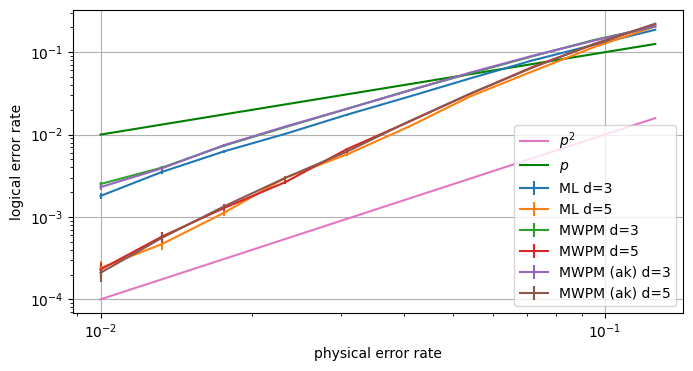

In [9]:
graphic.overlay_different_slopes(
    [log_error_rates_ML, log_error_rates_MWPM, log_error_rates_MWPM_AK],
    [y_errs_ML, y_errs_MWPM, y_errs_MWPM_AK],
    distances=distances,
    noise_set=noise_set,
    titles=["ML", "MWPM", "MWPM (ak)"],
    reference_lines=True,
)

<Figure size 640x480 with 0 Axes>

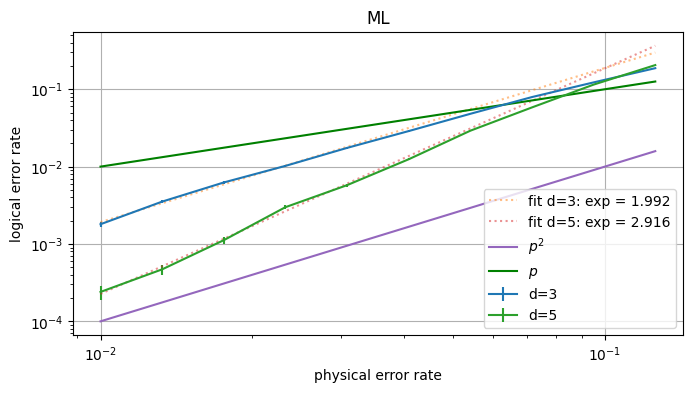

<Figure size 640x480 with 0 Axes>

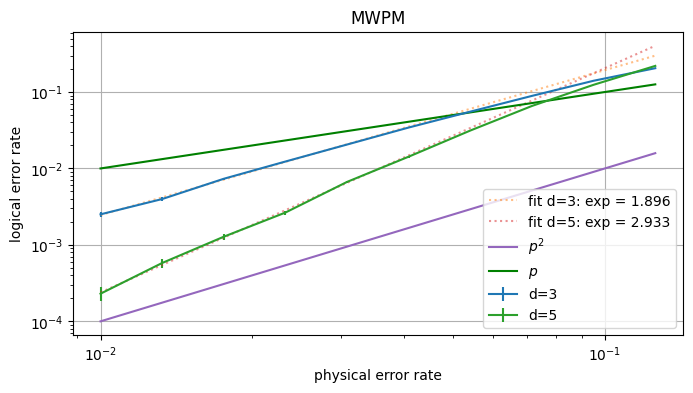

In [10]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="ML"
    ) 
graphic.plot_diff_noise_level(
        log_error_rates_MWPM,
        y_errs_MWPM,
        distances,
        noise_set,
        fit_slopes = True,
        reference_lines = True,
        title="MWPM"
    ) 